## 바이오 빅데이터 분석 (1B): Statistics, Correlation, Dimension Reduction, Clustering, Imputation

### 이 노트북의 목적
이 노트북은 1A에서 준비한 pandas/시각화 기초를 바탕으로, 바이오 빅데이터 분석에서 자주 사용하는 통계검정, 상관분석, 차원축소, 군집화, 결측치 처리 흐름을 실습합니다.

### 실습 주제
1. Box plot과 그룹 간 통계검정
2. Pearson 상관계수(PCC)를 이용한 유전자 간 관계 분석
3. PCA, t-SNE를 이용한 차원축소와 데이터 분포 시각화
4. k-means, GMM, Louvain algorithm을 이용한 군집화 맛보기
5. CCLE-CTRPv2 AUC 데이터의 결측치 확인과 imputation 실습

### 사용할 데이터
1. TCGA-BRCA cohort: 유방암 gene expression과 clinical subtype
2. CCLE-CTRPv2: 암세포주 gene expression과 약물 반응 AUC

#### Machine Learning and Bioinformatics (MLBI) Lab


## 0. 필요한 패키지 설치 (처음 한번만 하면 됨)

In [ ]:
# 수업 환경에서 mlbi-lab 또는 scikit-network가 없을 때만 주석을 해제하고 실행하세요.
# !pip install mlbi-lab scikit-network statannotations

In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, kruskal

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import cluster, mixture
from sklearn.neighbors import kneighbors_graph

from sknetwork.clustering import Louvain
from mlbi.datasets import load_data

## 1B 실습 준비: 데이터 불러오기와 공통 전처리

아래 셀은 이 노트북을 1A와 별도로 열어도 바로 실행할 수 있도록 필요한 데이터를 다시 불러오고, 이후 섹션에서 공통으로 사용할 분석용 table을 준비합니다.


In [ ]:
data = load_data('tcga-brca')

df_gep = data['gene_expression']
df_clinical = data['clinical_info']
df_log_gep = np.log10(df_gep + 1)

marker_genes = ['ESR1', 'ERBB2', 'MKI67']
df = df_log_gep[marker_genes].copy(deep=True)
df['subtype'] = df_clinical['subtype'].copy(deep=True)

PAM50_genes = ['ACTR3B', 'ANLN', 'BAG1', 'BCL2', 'BIRC5', 'BLVRA', 'CCNB1', 'CCNE1', 'CDC20', 'CDC6', 'CDH3', 'CENPF', 'CEP55', 'CXXC5', 'EGFR', 'ERBB2', 'ESR1', 'EXO1', 'FGFR4', 'FOXA1', 'FOXC1', 'GPR160', 'GRB7', 'KIF2C', 'KRT14', 'KRT17', 'KRT5', 'MAPT', 'MDM2', 'MELK', 'MIA', 'MKI67', 'MLPH', 'MMP11', 'MYBL2', 'MYC', 'NAT1', 'NDC80', 'NUF2', 'ORC6L', 'PGR', 'PHGDH', 'PTTG1', 'RRM2', 'SFRP1', 'SLC39A6', 'TMEM45B', 'TYMS', 'UBE2C', 'UBE2T']
PAM50_genes = list(set(PAM50_genes).intersection(df_log_gep.columns.values))

print('gene expression:', df_gep.shape)
print('clinical info:', df_clinical.shape)
print('analysis table:', df.shape)
print('PAM50 genes available:', len(PAM50_genes))


## 3. Box plot과 그룹 간 통계검정

Box plot은 그룹별 분포 차이를 눈으로 확인하는 데 유용하지만, 그림만으로 차이가 통계적으로 유의한지 판단할 수는 없습니다.  
아래에서는 `ERBB2` 발현량이 유방암 subtype 사이에서 다른지 간단히 검정합니다.

- 두 그룹 비교: t-test 또는 Mann-Whitney U test
- 세 그룹 이상 비교: ANOVA 또는 Kruskal-Wallis test

유전자 발현량은 정규분포가 아닐 수 있으므로, 여기서는 예시로 비모수 검정인 Kruskal-Wallis와 Mann-Whitney U test를 함께 사용합니다.

In [ ]:
# 분석에 사용할 subtype 순서를 정합니다.
# 데이터에 존재하는 subtype만 자동으로 사용합니다.

preferred_order = ['Basal', 'Her2', 'Lum.A', 'Lum.B']
available_subtypes = df['subtype'].dropna().unique().tolist()
order = [x for x in preferred_order if x in available_subtypes]
order += [x for x in available_subtypes if x not in order]

box_df = df[['subtype', 'ERBB2']].dropna().copy()

# plot에서 subtype이 원하는 순서(order)대로 보이도록 범주형 변수로 지정합니다.
box_df['subtype'] = pd.Categorical(box_df['subtype'], categories=order, ordered=True)

order

##### Kruskal-Wallis test for three or more groups

In [ ]:
# 세 그룹 이상 전체 비교: Kruskal-Wallis test
# 귀무가설: 모든 subtype의 ERBB2 발현량 분포가 같다.

groups = [
    box_df.loc[box_df['subtype'] == subtype, 'ERBB2']
    for subtype in order
]

stat, p_value = kruskal(*groups)
print(f'Kruskal-Wallis test statistic = {stat:.3f}')
print(f'p-value = {p_value:.3e}')

##### Mann-Whitney U test and t-test for two groups

In [ ]:
# 두 그룹 비교: Mann-Whitney U test & t-test
# 귀무가설: Her2와 Lum.A의 ERBB2 발현량 분포가 같다.
# 참고: Mann-Whitney U test는 두 그룹의 평균이 아니라 분포 차이를 비교하는 비모수 검정입니다.

group1_name = 'Her2'
group2_name = 'Lum.A'

group1 = box_df.loc[box_df['subtype'] == group1_name, 'ERBB2']
group2 = box_df.loc[box_df['subtype'] == group2_name, 'ERBB2']

stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')

print(f'{group1_name} vs {group2_name}')
print(f'Mann-Whitney U statistic = {stat:.3f}')
print(f'p-value = {p_value:.3e}')


stat, p_value = ttest_ind(group1, group2, equal_var=False)

print(f'{group1_name} vs {group2_name}')
print(f't-test statistic = {stat:.3f}')
print(f'p-value = {p_value:.3e}')

In [ ]:
# 여러 subtype을 두 그룹씩 pairwise t-test로 비교
# 주의: 여러 번 검정하면 false positive가 늘어나므로 p-value 보정이 필요할 수 있습니다.

from itertools import combinations

for group1_name, group2_name in combinations(order, 2):
    group1 = box_df.loc[box_df['subtype'] == group1_name, 'ERBB2']
    group2 = box_df.loc[box_df['subtype'] == group2_name, 'ERBB2']

    stat, p_value = ttest_ind(group1, group2, equal_var=False)

    print(f'{group1_name} vs {group2_name}')
    print(f'  t-test statistic = {stat:.3f}')
    print(f'  p-value = {p_value:.3e}')

#### Boxplot에 p-value 표시하기: statannotations

`statannotations` 패키지를 사용하면 seaborn boxplot 위에 그룹 간 비교 결과를 직접 표시할 수 있습니다.  
수업 환경에 패키지가 없다면 설치 셀에서 `!pip install statannotations` 주석을 해제한 뒤 실행하세요.

In [ ]:
from statannotations.Annotator import Annotator

pairs = []
for pair in [
    ('Her2', 'Lum.A'),
    ('Her2', 'Lum.B'),
    ('Basal', 'Lum.A'),
]:
    if set(pair).issubset(set(order)):
        pairs.append(pair)

plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=box_df, x='subtype', y='ERBB2', order=order, hue = 'subtype')
sns.stripplot(data=box_df, x='subtype', y='ERBB2', order=order, color='black', alpha=0.25, size=2)

annotator = Annotator(ax, pairs, data=box_df, x='subtype', y='ERBB2', order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='outside', verbose=0)
annotator.apply_and_annotate()

plt.xlabel('Subtype')
plt.ylabel('ERBB2 expression (log10 TPM + 1)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Pearson 상관계수 구하기

Pearson correlation coefficient(PCC, r)는 두 연속형 변수가 얼마나 직선적인 관계를 가지는지 나타내는 값입니다.

- `r`이 +1에 가까움: 한 유전자의 발현량이 증가할 때 다른 유전자의 발현량도 증가하는 경향
- `r`이 0에 가까움: 두 유전자 발현량 사이의 뚜렷한 선형 관계가 약함
- `r`이 -1에 가까움: 한 유전자의 발현량이 증가할 때 다른 유전자의 발현량은 감소하는 경향

사용할 데이터: TCGA-BRCA gene expression data

In [ ]:
# TCGA-BRCA gene expression data와 clinical metadata를 불러옵니다.

data = load_data('tcga-brca')

df_gep = data['gene_expression']
df_clinical = data['clinical_info']

In [ ]:
df_clinical.columns.values

In [ ]:
df_gep.columns.values

In [ ]:
# 이번 섹션에서는 gene expression table을 사용합니다.
# 발현량 분포가 한쪽으로 치우쳐 있기 때문에 log10(TPM + 1)로 변환한 값을 사용합니다.

df_log_gep = np.log10(df_gep + 1)

df_log_gep.head()

#### PCC 값에 따른 산점도 모양

먼저 인위적으로 만든 간단한 데이터로 PCC가 양수, 0 근처, 음수일 때 산점도가 어떻게 보이는지 확인합니다.  
PCC는 “점들이 직선 방향으로 얼마나 잘 모이는가”를 요약하는 값이라고 생각하면 됩니다.

In [ ]:
# PCC 값에 따른 산점도 예시

rng = np.random.default_rng(0)
x = np.linspace(-3, 3, 80)

pcc_examples = pd.DataFrame({
    'x': x,
    'positive': x + rng.normal(0, 0.8, size=len(x)),
    'near_zero': rng.normal(0, 1.2, size=len(x)),
    'negative': -x + rng.normal(0, 0.8, size=len(x)),
})

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharex=True, sharey=True)

for ax, col, title in zip(
    axes,
    ['positive', 'near_zero', 'negative'],
    ['Positive correlation', 'Near-zero correlation', 'Negative correlation']
):
    r, p_value = pearsonr(pcc_examples['x'], pcc_examples[col])
    sns.scatterplot(data=pcc_examples, x='x', y=col, ax=ax)
    ax.set_title(f'{title}\nr = {r:.2f}, p = {p_value:.1e}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()


#### 실제 TCGA-BRCA 유전자 발현 데이터에서 PCC 계산하기

이제 실제 유전자 두 개를 골라 PCC를 계산하고 산점도로 확인합니다.  
`pearsonr()` 함수는 PCC 값과 p-value를 함께 반환합니다.

In [ ]:
gene_x = 'ESR1'
gene_y = 'AGR2'

corr_df = df_log_gep[[gene_x, gene_y]].dropna()
r, p_value = pearsonr(corr_df[gene_x], corr_df[gene_y])

print(f'{gene_x} vs {gene_y}')
print(f'Pearson r = {r:.3f}')
print(f'p-value = {p_value:.3e}')

In [ ]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=corr_df, x=gene_x, y=gene_y, alpha=0.6)
sns.regplot(data=corr_df, x=gene_x, y=gene_y, scatter=False, color='red')

plt.title(f'{gene_x} vs {gene_y}\nPearson r = {r:.2f}')
plt.xlabel(gene_x)
plt.ylabel(gene_y)
plt.tight_layout()
plt.show()

#### 여러 유전자 간 상관계수 한 번에 보기

`DataFrame.corr()`를 사용하면 여러 변수 사이의 Pearson 상관계수를 행렬 형태로 계산할 수 있습니다.  
아래 heatmap에서는 양의 상관은 붉은색, 음의 상관은 푸른색에 가깝게 표시됩니다.

In [ ]:
# 유방암 subtype 구분과 관련이 있는 대표 marker gene 5개를 예시로 사용합니다.

selected_genes = ['ESR1', 'PGR', 'ERBB2', 'MKI67', 'FOXA1']
selected_genes = [gene for gene in selected_genes if gene in df_log_gep.columns]

corr_matrix = df_log_gep[selected_genes].corr(method='pearson')

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Pearson correlation among selected genes')
plt.tight_layout()
plt.show()

### Homework

1. CancerSEEK 데이터에서 39개 단백질 간 Pearson 상관계수 행렬을 계산하라.
2. 자기 자신과의 상관계수와 중복된 단백질쌍을 제외한 뒤, 양의 상관계수가 가장 큰 단백질쌍 3개와 음의 상관계수가 가장 작은 단백질쌍 3개를 골라라.
3. 2에서 선택된 단백질들을 모아 Pearson correlation heatmap을 그려라.

Hint: `df.corr()`, `unstack()`, `sort_values()`를 사용할 수 있다.

## 여기부터는 심화 맛보기입니다

아래의 PCA, t-SNE, clustering은 파이썬 기초보다는 머신러닝/다변량 분석에 가까운 내용입니다.  
이번 노트북에서는 수식보다 “많은 유전자를 한 번에 보고 subtype 구조를 관찰하는 도구”라는 관점으로 실행과 해석에 집중합니다.


## 5. 차원 축소와 데이터 분포의 시각화

#### 차원축소의 개념도

<div style="display:flex; gap:24px; align-items:flex-start;">
  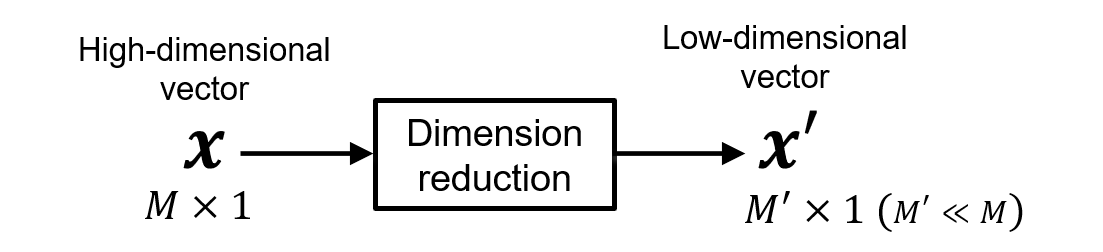  
</div>


#### Two approaches typically used
1.  PCA:  https://datascienceschool.net/view-notebook/f10aad8a34a4489697933f77c5d58e3a/ (전처리용)
2.  tSNE:  https://umap-learn.readthedocs.io/en/latest/basic_usage.html (시각화용)

사용할 데이터: TCGA-BRCA

#### PCA를 적용하여 2차원 축소한 후 데이터 분포 시각화

#### (1) Log transform of normalized GEP

In [ ]:
PAM50_genes = ['ACTR3B', 'ANLN', 'BAG1', 'BCL2', 'BIRC5', 'BLVRA',
 'CCNB1', 'CCNE1', 'CDC20', 'CDC6', 'CDH3', 'CENPF', 'CEP55',
 'CXXC5', 'EGFR', 'ERBB2', 'ESR1', 'EXO1', 'FGFR4', 'FOXA1',
 'FOXC1', 'GPR160', 'GRB7', 'KIF2C', 'KRT14', 'KRT17', 'KRT5',
 'MAPT', 'MDM2', 'MELK', 'MIA', 'MKI67', 'MLPH', 'MMP11', 'MYBL2',
 'MYC', 'NAT1', 'NDC80', 'NUF2', 'ORC6L', 'PGR', 'PHGDH', 'PTTG1',
 'RRM2', 'SFRP1', 'SLC39A6', 'TMEM45B', 'TYMS', 'UBE2C', 'UBE2T']

PAM50_genes = list(set(PAM50_genes).intersection(df_gep.columns.values))
len(PAM50_genes)

In [ ]:
X = df_log_gep[PAM50_genes]
y = df_clinical['subtype']

#### (2) PCA를 적용하여 2차원 축소한 후 데이터 분포 시각화

In [ ]:
## create PCA object
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X)

In [ ]:
df_2d = pd.DataFrame(X_2d, columns = ['PC1', 'PC2'])
df_2d['subtype'] = list(y)

In [ ]:
plt.figure(figsize = (5,5))
sns.scatterplot(x = df_2d['PC1'], y = df_2d['PC2'], hue = df_2d['subtype']);

#### (3) tSNE(비선형 차원축소, 교재 12장)을 이용한 데이터 시각화

In [ ]:
X_2d_tsne = TSNE(learning_rate=300, init='pca').fit_transform(X)
print(X.shape, X_2d_tsne.shape)

In [ ]:
df_2d_tsne = pd.DataFrame(X_2d_tsne, columns = ['D1', 'D2'])
df_2d_tsne['subtype'] = list(y)

In [ ]:
plt.figure(figsize = (6,6))
sns.scatterplot(data = df_2d_tsne, x = 'D1', y = 'D2', hue = 'subtype');

In [ ]:
plt.figure(figsize = (6,6))
sns.scatterplot(data = df_2d_tsne, x = 'D1', y = 'D2');

## 6. 군집화 (Clustering)

Objective is to divide data into a set of groups based on some similarity measures
<br>
<br>
Some typical algorithms:

1. k-means: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
2. Gaussian mixture model: https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html
3. Louvain algorithm: https://scikit-network.readthedocs.io/en/latest/tutorials/clustering/louvain.html

사용할 데이터: TCGA-BRCA

#### (1) Preprocessing and Dimension reduction using PCA

In [ ]:
PAM50_genes = ['ACTR3B', 'ANLN', 'BAG1', 'BCL2', 'BIRC5', 'BLVRA',
 'CCNB1', 'CCNE1', 'CDC20', 'CDC6', 'CDH3', 'CENPF', 'CEP55',
 'CXXC5', 'EGFR', 'ERBB2', 'ESR1', 'EXO1', 'FGFR4', 'FOXA1',
 'FOXC1', 'GPR160', 'GRB7', 'KIF2C', 'KRT14', 'KRT17', 'KRT5',
 'MAPT', 'MDM2', 'MELK', 'MIA', 'MKI67', 'MLPH', 'MMP11', 'MYBL2',
 'MYC', 'NAT1', 'NDC80', 'NUF2', 'ORC6L', 'PGR', 'PHGDH', 'PTTG1',
 'RRM2', 'SFRP1', 'SLC39A6', 'TMEM45B', 'TYMS', 'UBE2C', 'UBE2T']

PAM50_genes = list(set(PAM50_genes).intersection(df_gep.columns.values))
len(PAM50_genes)

In [ ]:
X = df_log_gep[PAM50_genes]
y = df_clinical['subtype']

In [ ]:
N_components = 10
pca_obj = PCA(n_components = N_components, copy = True, random_state = 0)
pca_res = pca_obj.fit(X)

X_pca = pca_obj.fit_transform(X)

In [ ]:
print(pca_res.components_.shape, X.shape, X_pca.shape)
print(pca_res.explained_variance_ratio_)
np.sum(pca_res.explained_variance_ratio_)

In [ ]:
X_pca.shape

In [ ]:
plt.figure(num=None, figsize=(8, 4), dpi=80, facecolor='w', edgecolor='k')

plt.bar(np.arange(X_pca.shape[1]), pca_res.explained_variance_ratio_)
plt.xlabel('PCs')
plt.ylabel('Explained Variance Ratio')
plt.grid()
plt.title('Test')
plt.show()

#### (2) Further dimension reduction using tSNE

In [ ]:
X_2d_tsne = TSNE(learning_rate=300, init='pca').fit_transform(X_pca)
X_2d_tsne.shape, X_pca.shape

In [ ]:
df_2d_tsne = pd.DataFrame(X_2d_tsne, columns = ['D1', 'D2'])
df_2d_tsne['label'] = list(y)

In [ ]:
df_2d_tsne.head()

In [ ]:
plt.figure(figsize = (6,6))
g = sns.scatterplot(data = df_2d_tsne, x = 'D1', y = 'D2')

#### (3a) k-means clustering

In [ ]:
N_clusters = 4
km = cluster.KMeans(n_clusters = N_clusters, random_state = 1)
km.fit(X_pca)
df_2d_tsne['cluster_km'] = km.labels_

In [ ]:
df_2d_tsne.head()

In [ ]:
df_2d_tsne['cluster_km'].value_counts()

In [ ]:
plt.figure(figsize = (6,6))
g = sns.scatterplot(data = df_2d_tsne, x = 'D1', y = 'D2',
                hue = 'cluster_km', palette = 'Spectral', legend='full')
g.legend(loc='right', bbox_to_anchor=(1.25, 0.5), ncol=1)

#### (3b) GMM clustering

In [ ]:
N_clusters = 4
gmm = mixture.GaussianMixture(n_components = N_clusters, random_state = 0)
df_2d_tsne['cluster_gmm'] = gmm.fit_predict(X_pca)

In [ ]:
df_2d_tsne.head()

In [ ]:
plt.figure(figsize = (6,6))
g = sns.scatterplot(data = df_2d_tsne, x = 'D1', y = 'D2',
                hue = 'cluster_gmm', palette = 'Spectral', legend='full')
g.legend(loc='right', bbox_to_anchor=(1.25, 0.5), ncol=1)

#### (3c) clustering using Louvain algorithm

In [ ]:
adj = kneighbors_graph(X_pca, 10, mode='connectivity', include_self=True)
louvain = Louvain(resolution = 0.5)
cluster_label = louvain.fit_predict(adj)

df_2d_tsne['cluster_louvain'] = cluster_label

In [ ]:
plt.figure(figsize = (6,6))
g = sns.scatterplot(data = df_2d_tsne, x = 'D1', y = 'D2',
                hue = 'cluster_louvain', palette = 'Spectral', legend='full')
g.legend(loc='right', bbox_to_anchor=(1.25, 0.5), ncol=1)

In [ ]:
df_2d_tsne

In [ ]:
# subtype label과 세 가지 clustering 결과를 한 번에 비교합니다.
# 같은 t-SNE 좌표를 사용하므로 색이 달라질 때 그룹 구조가 어떻게 보이는지 비교할 수 있습니다.

plot_targets = [
    ('label', 'Known subtype'),
    ('cluster_km', 'k-means cluster'),
    ('cluster_gmm', 'GMM cluster'),
    ('cluster_louvain', 'Louvain cluster'),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (hue_col, title) in zip(axes, plot_targets):
    sns.scatterplot(
        data=df_2d_tsne,
        x='D1',
        y='D2',
        hue=hue_col,
        palette='Spectral',
        legend='full',
        s=35,
        alpha=0.85,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('t-SNE D1')
    ax.set_ylabel('t-SNE D2')
    ax.legend(loc='best', fontsize=8, title=hue_col)

plt.tight_layout()
plt.show()


## 7. 결측치와 Imputation 실습

실제 바이오 빅데이터에서는 모든 샘플과 모든 feature가 완벽하게 측정되어 있지 않은 경우가 많습니다.  
이번 실습에서는 CCLE-CTRPv2 약물 반응 데이터의 AUC matrix를 사용하여 결측치를 확인하고, 간단한 imputation 방법을 비교합니다.

- AUC matrix의 행(row): cell line
- AUC matrix의 열(column): compound
- 값(value): 해당 cell line에서 측정된 compound별 AUC

AUC는 연속형 수치이므로 평균/중앙값 imputation 예제로 사용하기 좋습니다.

In [ ]:
# CCLE-CTRPv2 데이터 불러오기

data = load_data('ccle-ctrpv2')

df_auc = data['auc']
df_cl_info = data['cellline_info']
df_drug_info = data['drug_info']

df_auc.shape

### 결측치 확인

먼저 compound별로 결측치가 얼마나 있는지 확인합니다.  
`isnull().sum()`은 결측치 개수, `isnull().mean()`은 결측치 비율을 계산합니다.

In [ ]:
missing_summary = pd.DataFrame({
    'n_missing': df_auc.isnull().sum(),
    'missing_rate': df_auc.isnull().mean(),
    'n_observed': df_auc.notnull().sum(),
})

missing_summary = missing_summary.sort_values('missing_rate', ascending=False)
missing_summary.head(10)

### 인위적 결측치 만들기

실제 결측치가 있는 데이터에서는 imputation 결과가 얼마나 원래 값과 가까운지 알기 어렵습니다.  
그래서 관측값이 있는 일부 데이터에 인위적으로 결측치를 만든 뒤, imputation 결과를 원래 값과 비교해 봅니다.

In [ ]:
# imputation 연습을 위해 결측치가 없는 행만 일부 사용합니다.
# 여기서는 선택한 5개 compound가 모두 측정된 cell line만 남깁니다.

X_complete = X_auc.dropna().copy()

print('Original selected AUC matrix:', X_auc.shape)
print('Complete cases only:', X_complete.shape)

X_complete.head()

In [ ]:
# 전체 값 중 10%를 랜덤하게 NaN으로 바꿉니다.

rng = np.random.default_rng(0)
missing_rate = 0.10

X_missing = X_complete.copy()
missing_mask = rng.random(X_missing.shape) < missing_rate
X_missing = X_missing.mask(missing_mask)

print('Artificial missing rate:', X_missing.isnull().mean().mean())
X_missing.head()

In [ ]:
# 원본 데이터와 인위적으로 결측치를 만든 데이터를 나란히 비교합니다.

compound_for_plot = selected_compounds[0]

compare_df = pd.DataFrame({
    'original': X_complete[compound_for_plot],
    'with_missing': X_missing[compound_for_plot],
})

compare_df.head(10)

### 간단한 처리법 비교

결측치를 처리하는 가장 단순한 방법은 결측치가 있는 행을 제거하는 것입니다.  
하지만 결측치가 많으면 사용할 수 있는 샘플 수가 크게 줄어들 수 있습니다.

In [ ]:
# dropna(): 결측치가 하나라도 있는 cell line을 제거합니다.

X_dropna = X_missing.dropna()

print('Before dropna:', X_missing.shape)
print('After dropna:', X_dropna.shape)

In [ ]:
# compound별 평균으로 결측치 대체

X_mean_imputed = X_missing.fillna(X_missing.mean())

# compound별 중앙값으로 결측치 대체
X_median_imputed = X_missing.fillna(X_missing.median())

print('Missing values after mean imputation:')
print(X_mean_imputed.isnull().sum())

print('Missing values after median imputation:')
print(X_median_imputed.isnull().sum())

### scikit-learn SimpleImputer 사용하기

`SimpleImputer`를 사용하면 scikit-learn 방식으로 imputation을 수행할 수 있습니다.  
뒤에서 머신러닝 모델을 사용할 때는 이런 형태가 더 자연스럽습니다.

In [ ]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy='mean')
median_imputer = SimpleImputer(strategy='median')

X_mean_imputed_sklearn = pd.DataFrame(
    mean_imputer.fit_transform(X_missing),
    index=X_missing.index,
    columns=X_missing.columns,
)

X_median_imputed_sklearn = pd.DataFrame(
    median_imputer.fit_transform(X_missing),
    index=X_missing.index,
    columns=X_missing.columns,
)

X_median_imputed_sklearn.head()

### Imputation 전후 분포 비교

Imputation은 결측치를 실제 측정값처럼 복원하는 과정이 아닙니다.  
분석을 진행하기 위해 합리적인 값으로 대체하는 전처리이며, 값의 분포를 왜곡할 수 있으므로 결과 해석에 주의해야 합니다.

In [ ]:
plot_df = pd.DataFrame({
    'AUC': pd.concat([
        X_complete[compound_for_plot],
        X_missing[compound_for_plot].dropna(),
        X_mean_imputed[compound_for_plot],
        X_median_imputed[compound_for_plot],
    ]),
    'data_type': (
        ['original'] * X_complete.shape[0] +
        ['observed after masking'] * X_missing[compound_for_plot].dropna().shape[0] +
        ['mean imputed'] * X_mean_imputed.shape[0] +
        ['median imputed'] * X_median_imputed.shape[0]
    )
})

plt.figure(figsize=(8, 4))
sns.boxplot(data=plot_df, x='data_type', y='AUC')
plt.xlabel('')
plt.ylabel('AUC')
plt.title(f'Effect of imputation on AUC distribution {compound_for_plot}')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(X_complete[compound_for_plot], bins=25, kde=True, stat='density', alpha=0.35, label='original')
sns.histplot(X_mean_imputed[compound_for_plot], bins=25, kde=True, stat='density', alpha=0.35, label='mean imputed')
sns.histplot(X_median_imputed[compound_for_plot], bins=25, kde=True, stat='density', alpha=0.35, label='median imputed')

plt.xlabel('AUC')
plt.ylabel('Density')
plt.title(f'Original vs imputed AUC distribution {compound_for_plot}')
plt.legend()
plt.tight_layout()
plt.show()

### Homework

1. 결측치 비율이 10-30% 사이인 compound를 하나 고르고 AUC 분포를 그려라.
2. 해당 compound의 결측치를 평균과 중앙값으로 각각 대체하라.
3. imputation 전후 AUC 분포를 비교하고, 어떤 방법이 더 적절해 보이는지 간단히 설명하라.